
# Sentiment Analysis using NLP Pipeline & ML Models

This notebook demonstrates an end-to-end NLP pipeline:
**Raw Text → Cleaning → Preprocessing → Feature Engineering → Model Training → Evaluation → Comparison**


In [1]:

import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
    
# NOTE:
# Dataset is not included in repository due to size limits.
# Please download from Kaggle link provided in README.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# ===============================
# DATA LOADING & INITIAL CHECK
# ===============================

import pandas as pd

# Load dataset (using full path)
df = pd.read_csv(r"IMDB Dataset.csv")

# Rename columns to match pipeline
df = df.rename(columns={'review': 'text', 'sentiment': 'label'})

# Preview data
print("First 5 rows:")
print(df.head())

# Check columns
print("\nColumns:")
print(df.columns)

# Check shape
print("\nShape:")
print(df.shape)

# Check class distribution
print("\nClass Distribution:")
print(df['label'].value_counts())

First 5 rows:
                                                text     label
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Columns:
Index(['text', 'label'], dtype='object')

Shape:
(50000, 2)

Class Distribution:
label
positive    25000
negative    25000
Name: count, dtype: int64


In [3]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r"<.*?>", '', text)
    text = re.sub(r"\bbr\b", '', text)   #  REMOVE leftover 'br'
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [4]:
df['clean_text'] = df['text'].apply(clean_text)
print("Before:", df['text'][0])
print("\nAfter:", df['clean_text'][0])

Before: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to

In [5]:

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:

# Bag of Words
bow = CountVectorizer()
X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

# TF-IDF
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


In [7]:

models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier()
}


In [8]:

results = []

def evaluate(model, X_train, X_test, name, vectorizer):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\n{name} ({vectorizer})")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    return [name, vectorizer, acc, prec, rec, f1]


In [ ]:

for name, model in models.items():
    results.append(evaluate(model, X_train_bow, X_test_bow, name, "BoW"))
    results.append(evaluate(model, X_train_tfidf, X_test_tfidf, name, "TF-IDF"))

results_df = pd.DataFrame(results, columns=["Model","Vectorizer","Accuracy","Precision","Recall","F1"])
results_df


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression (BoW)
              precision    recall  f1-score   support

    negative       0.89      0.88      0.89      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Logistic Regression (TF-IDF)
              precision    recall  f1-score   support

    negative       0.91      0.88      0.90      4961
    positive       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000


Naive Bayes (BoW)
              precision    recall  f1-score   support

    negative       0.85      0.88      0.86      4961
    positive       0.88      0.85      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     1000

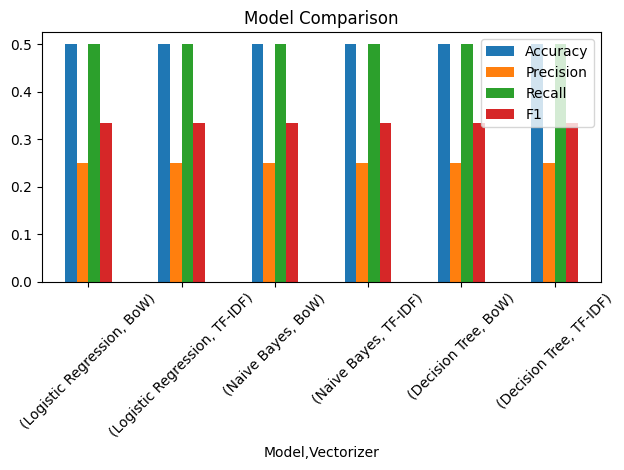

In [ ]:

results_df.set_index(['Model','Vectorizer'])[['Accuracy','Precision','Recall','F1']].plot(kind='bar')
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Conclusion

- TF-IDF generally performs better than BoW.
- Logistic Regression shows stable performance.
- Preprocessing significantly improves model performance.
- Choosing the right vectorization and model is crucial for NLP tasks.
